# SA-HTDemucs — Train & Evaluate the Spatial Cue Module

This notebook fine-tunes **only the `SpatialCueModule` heads** attached to a frozen, pre-trained HT-Demucs backbone (`SA-HTDemucs`).

- **What is trained:**  4 × `SpatialCueModule` (one per source)
- **What is frozen:**  All HT-Demucs backbone weights.
- **Training loss:**   Per-sub-band ILD MSE
- **Evaluation:**      Per-sub-band ILD MAE and SI-SDR against ground-truth stems on the binauralMUSDB18-HQ test split.

> **Prerequisite:** `pip install demucs`

In [5]:
import sys
from pathlib import Path

from sympy import false, true

_cwd = Path().resolve()
_project_root = next(
    (p for p in [_cwd, *_cwd.parents]
     if (p / 'sahtdemucs' / '__init__.py').exists()),
    _cwd.parent,
)
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import time
from datetime import datetime
import json
import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from demucs.pretrained import get_model
from sahtdemucs.model import SAHTDemucs
from sahtdemucs.dataset import MusdbSpatialDataset
from sahtdemucs.spatial import compute_ild_bands, compute_ild_bands_mel, mel_bin_assignment
from sahtdemucs.losses import SpatialLoss


## Configuration

In [6]:
# Remote server or local machine computing
remote          = True
training        = True

# ── Overfitting sanity check ──────────────────────────────────────────────────
OVERFIT_MODE    = False

# ── Paths ─────────────────────────────────────────────────────────────────────
if remote:
    DATASET_ROOT = Path("/nas/home/macerbi/Dataset/binauralMUSDB18HQ")
    CKPT_DIR     = Path("/nas/home/macerbi/sahtdemucs/runs")

    if training:
        _run_ts   = datetime.now().strftime("%Y%m%d_%H%M%S")
    else:
        _run_ts   = "20260424_191407"
    CKPT_PATH    = CKPT_DIR / f"spatial_modules_{_run_ts}.pt"
    HISTORY_PATH = CKPT_DIR / f"history_{_run_ts}.json"
    ESTIMATES_DIR = CKPT_DIR / f"estimates_{_run_ts}"
    SAVE_PLOT = False

else:
    DATASET_ROOT = Path(r"D:\Polimi\PhD\Dataset\binauralMUSDB18HQ")
    CKPT_DIR     = Path(r"H:\Il mio Drive\Polimi\PhD\Progetto di Ricerca\MSS & SSL\sahtdemucs\runs")

    if training:
        _run_ts   = datetime.now().strftime("%Y%m%d_%H%M%S")
    else:
        _run_ts   = "20260424_191407"
    CKPT_PATH    = CKPT_DIR / f"spatial_modules_{_run_ts}.pt"
    HISTORY_PATH = CKPT_DIR / f"history_{_run_ts}.json"
    ESTIMATES_DIR = Path(f"D:\Polimi\PhD\Dataset\SAHTDemucs\estimates_{_run_ts}")
    SAVE_PLOT = True
    PLOT_DIR = Path(r"H:\Il mio Drive\Polimi\PhD\Progetto di Ricerca\MSS & SSL\sahtdemucs\plot")

# ── Training hyper-parameters ─────────────────────────────────────────────────
if OVERFIT_MODE:
    N_EPOCHS        = 300
    BATCH_SIZE      = 1
    LR              = 1e-3
    VALID_SPLIT     = 0.0
    CROPS_PER_TRACK = 1
else:
    N_EPOCHS        = 250
    BATCH_SIZE      = 4
    LR              = 1e-3
    VALID_SPLIT     = 0.2
    CROPS_PER_TRACK = 4

N_WORKERS   = 0

# ── Loss weights ──────────────────────────────────────────────────────────────
# LAMBDA_SI controls the SI-SDR degradation penalty.
# Both terms are in dB, so lambdas are directly comparable:
#   - SI-SDR degradation: 0–3 dB when the spatial correction hurts separation
#   - ILD MSE: 10–100 dB² at start, converging toward 0
LAMBDA_SI       = 10.0
LAMBDA_ILD      = 1.0
# Maximum tolerated SI-SDR degradation (dB) relative to frozen HTDemucs baseline.
# Corrections that do not worsen SI-SDR beyond this margin produce zero gradient
# from the SI term, letting the ILD loss train freely.
SI_MARGIN_DB    = 0.2

# ── CNN parameters ──────────────────────────────────────────────────────────────
SPATIAL_ARCH        = "cnn2d"
N_FFT               = 4096
HOP_LEN             = 512
N_BANDS             = 64
ILD_SCALE           = 15.0
BAND_SCALE          = "mel"
USE_GLOBAL_BRANCH   = True

# ── Misc ──────────────────────────────────────────────────────────────────────
SOURCES = ["drums", "bass", "other", "vocals"]
COLORS  = ["#4c72b0", "#55a868", "#c44e52", "#8172b2"]
def _pick_free_gpu() -> torch.device:
    """Return the CUDA device with the most free memory; fall back to CPU."""
    if not torch.cuda.is_available():
        return torch.device("cpu")
    best_idx, best_free = 0, -1
    for i in range(torch.cuda.device_count()):
        try:
            free, _ = torch.cuda.mem_get_info(i)
        except Exception:
            free = 0
        if free > best_free:
            best_free, best_idx = free, i
    if best_free <= 0:
        print("Warning: all GPUs are fully occupied. Using cuda:0 anyway.")
    return torch.device(f"cuda:{best_idx}")

DEVICE  = _pick_free_gpu()

print(f"Dataset: {DATASET_ROOT}")
if training:
    print(f"Checkpoint will be saved to: {CKPT_PATH}")
    print(f"History    will be saved to: {HISTORY_PATH}")
else:
    print(f"Checkpoint loaded: {CKPT_PATH}")
    print(f"History    loaded: {HISTORY_PATH}")
print(f"Run    : {_run_ts}")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"Device name: {torch.cuda.get_device_name(DEVICE)}")
    print(f"VRAM: {torch.cuda.get_device_properties(DEVICE).total_memory / 1e9:.1f} GB")
if OVERFIT_MODE:
    print(rf"*** OVERFIT MODE — single fixed segment ***")

Dataset: /nas/home/macerbi/Dataset/binauralMUSDB18HQ
Checkpoint will be saved to: /nas/home/macerbi/sahtdemucs/runs/spatial_modules_20260529_131144.pt
History    will be saved to: /nas/home/macerbi/sahtdemucs/runs/history_20260529_131144.json
Run    : 20260529_131144
Device : cuda:1
Device name: NVIDIA TITAN RTX
VRAM: 25.4 GB


## Load SA-HTDemucs

`get_model` may return a `BagOfModels` (ensemble wrapper); we extract the first underlying `HTDemucs` instance so we can call it directly. `SAHTDemucs` freezes all backbone weights — only the 4 `SpatialCueModule` CNN heads (one per source) will be updated during training. Each `SpatialCueModule` has a **CNN**.

In [7]:
# HT-Demucs pre-trained backbone
bag  = get_model("htdemucs")
base = bag.models[0] if hasattr(bag, "models") else bag

# Load SAHTDemucs with specified parameters
model = SAHTDemucs(base,
                   spatial_arch    = SPATIAL_ARCH,
                   sources         = base.sources,
                   n_fft           = N_FFT,
                   hop_length      = HOP_LEN,
                   n_bands         = N_BANDS,
                   ild_scale       = ILD_SCALE,
                   band_scale      = BAND_SCALE,
                   sample_rate     = base.samplerate,
                   use_gb          = USE_GLOBAL_BRANCH
                   ).to(DEVICE)

# Print parameters
SAMPLE_RATE = base.samplerate
SEG_LEN     = int(float(base.segment) * SAMPLE_RATE)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"Base model       : {type(base).__name__}")
print(f"Sources          : {base.sources}")
print(f"Sample rate      : {SAMPLE_RATE} Hz")
print(f"HTDemucs segment : {float(base.segment):.2f} s  ({SEG_LEN} samples)")
print(f"ild_scale        : {ILD_SCALE} dB")
print(f"Trainable params : {n_trainable:,}")
print(f"Frozen params    : {n_frozen:,}")

Base model       : HTDemucs
Sources          : ['drums', 'bass', 'other', 'vocals']
Sample rate      : 44100 Hz
HTDemucs segment : 7.80 s  (343980 samples)
ild_scale        : 15.0 dB
Trainable params : 697,092
Frozen params    : 41,984,456


## Training Dataset

Each batch item is a random segment of exactly `SEG_LEN` samples — matching
the length expected by HTDemucs's internal temporal convolutions.

In [8]:
# Build MUSDB-like dataset
full_ds = MusdbSpatialDataset(
    DATASET_ROOT,
    split="train",
    sources=SOURCES,
    segment_len=SEG_LEN,
    sample_rate=SAMPLE_RATE,
    augment=False if OVERFIT_MODE else True,
    crops_per_track=1 if OVERFIT_MODE else CROPS_PER_TRACK,
)

if OVERFIT_MODE:
    # ── Overfitting sanity check: single fixed segment ────────────────────────
    # Load track 0 exactly once — the random crop is drawn here and then frozen.
    # Every epoch will see the exact same (mix, targets) tensor, so the model
    # must memorise it.  Loss should converge monotonically toward ~0.
    # If it does not, there is a bug in the gradient path.
    torch.manual_seed(0)
    mix_fixed, tgt_fixed = full_ds[0]          # (2, T), (S, 2, T)
    mix_fixed = mix_fixed.unsqueeze(0)         # (1, 2, T)
    tgt_fixed = tgt_fixed.unsqueeze(0)         # (1, S, 2, T)

    fixed_ds     = TensorDataset(mix_fixed, tgt_fixed)
    train_loader = DataLoader(fixed_ds, batch_size=1, shuffle=False, num_workers=0)
    valid_loader = DataLoader(fixed_ds, batch_size=1, shuffle=False, num_workers=0)

    print(f"OVERFIT MODE — track : '{full_ds.tracks[0].name}'")
    print(f"Fixed segment shape  : mix={tuple(mix_fixed.shape)}  targets={tuple(tgt_fixed.shape)}")
else:
    # Number of validation tracks
    n_valid = max(1, int(len(full_ds.tracks) * VALID_SPLIT))

    # Number of training tracks
    n_train = len(full_ds.tracks) - n_valid

    # Split at the track level, then build per-split datasets
    all_tracks   = full_ds.tracks
    train_tracks = all_tracks[:n_train]
    valid_tracks = all_tracks[n_train:]

    train_ds = MusdbSpatialDataset.__new__(MusdbSpatialDataset)
    train_ds.__dict__.update(full_ds.__dict__)
    train_ds.tracks          = train_tracks
    train_ds.crops_per_track = CROPS_PER_TRACK

    valid_ds = MusdbSpatialDataset.__new__(MusdbSpatialDataset)
    valid_ds.__dict__.update(full_ds.__dict__)
    valid_ds.tracks          = valid_tracks
    valid_ds.crops_per_track = 1   # single crop per track for validation

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=N_WORKERS, pin_memory=(DEVICE.type == "cuda"))
    valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=N_WORKERS, pin_memory=(DEVICE.type == "cuda"))

    print(f"Train tracks : {n_train}  ×  {CROPS_PER_TRACK} crops  =  {len(train_ds)} items  ({len(train_loader)} batches @ batch={BATCH_SIZE})")
    print(f"Valid tracks : {n_valid}   ({len(valid_loader)} batches)")

Train tracks : 80  ×  4 crops  =  320 items  (80 batches @ batch=4)
Valid tracks : 20   (5 batches)


In [9]:
if OVERFIT_MODE:
    # ── Diagnostics: distribution of required ILD corrections ─────────────────
    # For overfitting to converge to ~0, ild_scale must be >= max(|ILD_gt - ILD_est|).
    # This cell shows whether the current ild_scale is sufficient.
    model.eval()
    with torch.no_grad():
        mix_d, tgt_d = mix_fixed.to(DEVICE), tgt_fixed.to(DEVICE)
        est_d = model.base_model(mix_d)   # (1, S, 2, T) — before spatial correction

        print(f"{'Source':<8}  {'required delta (dB)':>22}   ild_scale={model.spatial_modules[0].ild_scale} dB")
        print(f"{'':8}  {'mean':>6} {'std':>6} {'p5':>6} {'p95':>6} {'max|Δ|':>8}")
        print("─" * 60)
        for s, src in enumerate(SOURCES):
            # ILD of raw HTDemucs output (before SpatialCueModule)
            # Access the backbone output directly: run HTDemucs only
            raw_est = est_d[:, s]        # (1, 2, T) — already corrected by spatial module
            gt_s    = tgt_d[:, s]        # (1, 2, T)

            # We want the *required* correction = ILD_gt - ILD_htdemucs_raw
            # Since we have the corrected output, approximate with ILD_gt - ILD_corrected
            ild_e = compute_ild_bands(raw_est[:, 0], raw_est[:, 1])  # (1, n_bands, T_frames)
            ild_g = compute_ild_bands(gt_s[:, 0],   gt_s[:, 1])

            delta_required = (ild_g - ild_e).abs().flatten()
            p = torch.quantile(delta_required.float(), torch.tensor([0.05, 0.95]).to(delta_required.device))
            print(f"{src:<8}  {delta_required.mean():>6.1f} {delta_required.std():>6.1f} "
                    f"{p[0]:>6.1f} {p[1]:>6.1f} {delta_required.max():>8.1f}")
    print()
    print("→ If p95 > ild_scale, increase ild_scale in the config upside.")

## Training — Spatial Cue Modules with per-sub-band ILD Supervision

Given the estimated stereo source $s$, the STFT spectrum of left channel $X_L(f,t)$ and the one of right channel $X_R(f,t)$ are both divided into $K$ frequency bands (equal-width on the linear scale when `BAND_SCALE="linear"`, or Mel-scale bands when `BAND_SCALE="mel"` — narrower at low frequencies for finer ILD resolution in the bass region). For band $k$ and STFT frame $t$, the ILD of the stereo source $s$ is:

$$ \widehat{\text{ILD}}_k^{(s)}(t) = 10\log_{10} \left( \frac{\dfrac{1}{|B_k|}\displaystyle\sum_{f\,\in\, B_k}\!|X_L^{(s)}(f,t)|^2}{\dfrac{1}{|B_k|}\displaystyle\sum_{f\,\in\, B_k}\!|X_R^{(s)}(f,t)|^2} \right) \quad\text{[dB]}$$

where $B_k$ is the set of STFT bins belonging to band $k$, and $X_L^{(s)}$, $X_R^{(s)}$ are the left and right channel STFTs of source $s$.

Each `SpatialCueModule` contains a CNN that maps $\widehat{\text{ILD}}_k^{(s)}(t)$ to a correction mask $\Delta \text{ILD}_k^{(s)}(t)$:

$$\delta_k^{(s)}(t) = f\!\left(\widehat{\text{ILD}}_k^{(s)}(t)\right) \in [-1,+1]^{K\times T_f}$$

which is then scaled by  $\alpha_{\text{ILD}}$ to have a proper correction in dB:

$$\Delta \text{ILD}_k^{(s)}(t) = \delta_k^{(s)}(t) \cdot \alpha_{\text{ILD}}$$

The training objective is the per-band ILD MSE averaged over the S sources:

$$ \mathcal{L} = \frac{1}{S} \sum_{s=1}^{S} \mathcal{L}_{\text{ILD}}^{(s)} $$

where

$$ \mathcal{L}_{\text{ILD}}^{(s)} = \frac{1}{K \cdot T_f} \sum_{k=1}^{K} \sum_{t=1}^{T_f} \left(\widehat{\text{ILD}}_k^{(s)}(t) - \text{ILD}_{k,\,\text{gt}}^{(s)}(t) \right)^2 $$

Since each `SpatialCueModule` is source-specific (one per source), the CNN for drums can learn a different correction function than vocals.  The model can learn systematic spatial biases that HTDemucs introduces per source class.

In [10]:
# Spatial Loss — STFT parameters must match the SpatialCueModule configuration
spatial_loss = SpatialLoss(
    lambda_si    = LAMBDA_SI,
    lambda_ild   = LAMBDA_ILD,
    si_margin_db = SI_MARGIN_DB,
    n_fft        = N_FFT,
    hop_length   = HOP_LEN,
    n_bands      = N_BANDS,
    band_scale   = BAND_SCALE,
    sample_rate  = SAMPLE_RATE,
)

@torch.no_grad()
def run_epoch_valid(model, batches):
    """Evaluate total loss and its two components on pre-loaded validation batches.

    Returns:
        (v_total, v_si, v_ild): mean values over all batches.
    """
    model.eval()
    tot_total, tot_si, tot_ild, n = 0.0, 0.0, 0.0, 0
    for mix, targets in batches:
        estimates, raw_estimates, _ = model(mix)
        loss, loss_si, loss_ild = spatial_loss(estimates, targets, raw_estimates)
        tot_total += loss.item()
        tot_si    += loss_si.item()
        tot_ild   += loss_ild.item()
        n += 1
    denom = max(n, 1)
    return tot_total / denom, tot_si / denom, tot_ild / denom

### Training loop

In [11]:
# Pre-load validation batches once with a fixed seed.
# Every epoch will evaluate the exact same segments, removing crop-position
# noise from the validation curve — only model-quality changes will remain.
torch.manual_seed(42)
fixed_valid_batches = [
    (mix.to(DEVICE), targets.to(DEVICE))
    for mix, targets in valid_loader
]
n_valid_segments = sum(m.shape[0] for m, _ in fixed_valid_batches)
print(f"Fixed {len(fixed_valid_batches)} validation batches ({n_valid_segments} segments total)")

Fixed 5 validation batches (20 segments total)


In [ ]:
import json

optimizer = torch.optim.Adam(model.trainable_parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=30,
    min_lr=1e-6,
)

history = {
    "train_total": [], "train_si": [], "train_ild": [],
    "valid_total": [], "valid_si": [], "valid_ild": [],
    "lr": [],
}
best_valid = float("inf")

for epoch in range(1, N_EPOCHS + 1):
    # ── Training pass ─────────────────────────────────────────────────────────
    model.train()
    tot_total, tot_si, tot_ild, n = 0.0, 0.0, 0.0, 0

    for mix, targets in train_loader:
        mix, targets = mix.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()

        estimates, raw_estimates, _ = model(mix)
        loss, loss_si, loss_ild = spatial_loss(estimates, targets, raw_estimates)
        loss.backward()
        optimizer.step()

        tot_total += loss.item()
        tot_si    += loss_si.item()
        tot_ild   += loss_ild.item()
        n += 1

    denom      = max(n, 1)
    mean_total = tot_total / denom
    mean_si    = tot_si    / denom
    mean_ild   = tot_ild   / denom

    # ── Validation pass (fixed segments — deterministic across epochs) ────────
    v_total, v_si, v_ild = run_epoch_valid(model, fixed_valid_batches)

    scheduler.step(v_ild)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_total"].append(mean_total)
    history["train_si"].append(mean_si)
    history["train_ild"].append(mean_ild)
    history["valid_total"].append(v_total)
    history["valid_si"].append(v_si)
    history["valid_ild"].append(v_ild)
    history["lr"].append(current_lr)

    # ── Persist history after every epoch (survives interrupted runs) ─────────
    HISTORY_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(HISTORY_PATH, "w") as _hf:
        json.dump(history, _hf)

    flag = ""
    if v_ild < best_valid:
        best_valid = v_ild
        flag = "  ← best"
        CKPT_PATH.parent.mkdir(parents=True, exist_ok=True)
        torch.save(model.spatial_modules.state_dict(), CKPT_PATH)

    print(
        f"Epoch {epoch:3d}/{N_EPOCHS}"
        f"  train: total={mean_total:.4f}  si={mean_si:.4f}  ild={mean_ild:.4f}"
        f"  │  valid: total={v_total:.4f}  si={v_si:.4f}  ild={v_ild:.4f}"
        f"  lr={current_lr:.2e}{flag}"
    )

print(f"\nTraining complete. Best checkpoint → {CKPT_PATH}")
print(f"History saved → {HISTORY_PATH}")

Epoch   1/250  train: total=79.5446  si=1.4056  ild=78.1390  │  valid: total=80.5989  si=3.5840  ild=77.0149  lr=1.00e-03  ← best
Epoch   2/250  train: total=73.9259  si=2.1448  ild=71.7811  │  valid: total=79.9237  si=3.5133  ild=76.4105  lr=1.00e-03  ← best
Epoch   3/250  train: total=72.0107  si=1.9911  ild=70.0196  │  valid: total=69.7083  si=3.9257  ild=65.7827  lr=1.00e-03  ← best
Epoch   4/250  train: total=67.8589  si=1.8915  ild=65.9674  │  valid: total=70.3375  si=3.5051  ild=66.8324  lr=1.00e-03
Epoch   5/250  train: total=66.1153  si=2.3026  ild=63.8128  │  valid: total=70.3560  si=4.8630  ild=65.4930  lr=1.00e-03  ← best
Epoch   6/250  train: total=66.9681  si=2.0590  ild=64.9092  │  valid: total=67.5912  si=4.6888  ild=62.9023  lr=1.00e-03  ← best
Epoch   7/250  train: total=64.7596  si=2.4971  ild=62.2625  │  valid: total=68.0442  si=4.4511  ild=63.5931  lr=1.00e-03
Epoch   8/250  train: total=64.0606  si=1.8030  ild=62.2576  │  valid: total=66.1030  si=4.9915  ild=61.11

## Load Checkpoint (run this cell to skip training)

If training was already completed in a previous session, load the saved spatial
module weights and the history json instead of re-training.

In [ ]:
model.spatial_modules.load_state_dict(
    torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
)
model.eval()
print(f"Spatial modules loaded from {CKPT_PATH}")

# Load training history so the plot cells work without re-training
if HISTORY_PATH.exists():
    with open(HISTORY_PATH) as _hf:
        history = json.load(_hf)
    print(f"History loaded from {HISTORY_PATH}  ({len(history['train_total'])} epochs)")
else:
    print(f"Warning: history file not found at {HISTORY_PATH} — plot cells will be empty")

### Plot training metrics

In [ ]:
epochs = np.arange(1, len(history["train_total"]) + 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 8), dpi=120)

_curves = [
    # (train_key,       valid_key,       title,                   ylabel)
    ("train_total",  "valid_total",  "Total loss",            "λ_si·L_si + λ_ild·L_ild"),
    ("train_ild",    "valid_ild",    "ILD MSE (spatial)",     "dB²"),
    ("train_si",     "valid_si",     "SI-SDR degradation",    "dB"),
]

for col, (tk, vk, title, ylabel) in enumerate(_curves):
    for row, (key, label, color) in enumerate([
        (tk, "train", "#2196F3"),
        (vk, "valid", "#FF5722"),
    ]):
        ax = axes[row, col]
        ax.plot(epochs, history[key], color=color, lw=1.6, label=label)
        ax.set_title(f"{'Train' if row == 0 else 'Valid'} — {title}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend(fontsize=9)
        ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
        ax.set_axisbelow(True)

# Learning-rate curve replaces the bottom-right empty slot
ax_lr = axes[1, 2]
ax_lr.plot(epochs, history["lr"], color="#9C27B0", lw=1.6)
ax_lr.set_title("Learning rate")
ax_lr.set_xlabel("Epoch")
ax_lr.set_ylabel("LR")
ax_lr.set_yscale("log")
ax_lr.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
ax_lr.set_axisbelow(True)

plt.suptitle("SA-HTDemucs training curves", fontsize=14)
plt.tight_layout()

if SAVE_PLOT:
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(PLOT_DIR / "train_metrics.png", bbox_inches="tight")

plt.show()

## Evaluation on the Test split

Each track is processed in **non-overlapping chunks** of exactly `SEG_LEN` samples (the length HT-Demucs was trained on).  The last chunk is zero-padded to `SEG_LEN` and the result is trimmed back to the original length.

## SI-SDR
To check if separation quality is preserved Scale-Invariant Signal-To-Distortion Ratio (SI-SDR) is computed per each corrected source $\hat{s}^{(s)}$, with respect to groundtruth source $s_{gt}^{(s)}$ as:

$$ \text{SI-SDR}(\hat{s}^{(s)}, s_{gt}^{(s)}) = 10 \cdot \log_{10} \left( \frac{\left\| \dfrac{\langle \hat{s}^{(s)}, s_{gt}^{(s)} \rangle}{\|s_{gt}^{(s)}\|^2} \cdot s_{gt}^{(s)} \right\|^2} {\left\| \hat{s}^{(s)} - \dfrac{\langle \hat{s}^{(s)}, s_{gt}^{(s)} \rangle}{\|s_{gt}^{(s)}\|^2} \cdot s_{gt}^{(s)} \right\|^2} \right) \quad \text{[dB]}$$

## Per-Band ILD MAE

Primary metric for evaluating the sub-band spatial correction.
Each curve shows, for one virtual source $s$, how much residual ILD error remains per frequency band — and whether the correction reduces it relative to the HTDemucs baseline.

For each test track $n$ and source $s^{(s)}$, the ILD trajectory is averaged over time before taking the absolute difference between estimate and ground truth:

$$ \mathrm{MAE}_{k}(\hat{s}^{(s)}, s_{gt}^{(s)}) = \frac{1}{T_f} \sum_{t=1}^{T_f} \left| \widehat{\mathrm{ILD}}_k^{(s)}(t) - \mathrm{ILD}_{k,\,\mathrm{gt}}^{(s)}(t) \right| \quad\text{[dB]}$$

The centre frequency of band $k$ is  $\dfrac{k}{K}\cdot\dfrac{f_s}{2}$, with $K=32$ and $f_s=44100$ Hz.

In [10]:
def load_stem(path: Path) -> torch.Tensor:
    """Load a WAV and return (2, T) at SAMPLE_RATE."""
    wav, sr = torchaudio.load(str(path))
    if wav.shape[0] == 1:
        wav = wav.repeat(2, 1)
    elif wav.shape[0] > 2:
        wav = wav[:2]
    if sr != SAMPLE_RATE:
        wav = torchaudio.functional.resample(wav, sr, SAMPLE_RATE)
    return wav

def separate_baseline(wav: torch.Tensor) -> torch.Tensor:
    """Run HTDemucs backbone only -- no spatial correction. Returns (S, 2, T)."""
    from demucs.apply import apply_model
    model.eval()
    return apply_model(
        model.base_model,
        wav.unsqueeze(0),
        progress=False,
    ).squeeze(0)  # (S, 2, T)

# -- Sub-band parameters -- read from trained model
_EVAL_N_FFT  = model.spatial_modules[0].n_fft       # e.g. 2048
_EVAL_HOP    = model.spatial_modules[0].hop_length  # e.g. 512
_EVAL_BANDS  = model.spatial_modules[0].n_bands     # e.g. 64
_EVAL_SCALE  = model.spatial_modules[0].band_scale  # 'linear' or 'mel'
_EVAL_SR     = model.spatial_modules[0].sample_rate # e.g. 44100

def compute_si_sdr(est: torch.Tensor, tgt: torch.Tensor) -> float:
    """Scale-invariant SDR in dB between two stereo tensors (2, T)."""
    e = est.float().reshape(-1)
    t = tgt.float().reshape(-1)
    e = e - e.mean()
    t = t - t.mean()
    alpha = (e * t).sum() / (t * t).sum().clamp(min=1e-8)
    proj  = alpha * t
    noise = e - proj
    return 10 * torch.log10((proj ** 2).sum() / (noise ** 2).sum().clamp(min=1e-8)).item()

def compute_ild_bands_mae(est: torch.Tensor, tgt: torch.Tensor) -> np.ndarray:
    """Per-sub-band ILD MAE between estimated and groundtruth (2, T).

    Uses the same band scale (linear or Mel) as the trained model so that
    the evaluation metric is consistent with the training loss.

    Returns:
        (n_bands,) array of mean absolute ILD error in dB.
    """
    if _EVAL_SCALE == 'mel':
        def _ild_fn(l, r):
            return compute_ild_bands_mel(
                l, r,
                n_fft=int(_EVAL_N_FFT), hop_length=int(_EVAL_HOP),
                n_bands=int(_EVAL_BANDS), sample_rate=int(_EVAL_SR),
            )
    else:
        def _ild_fn(l, r):
            return compute_ild_bands(
                l, r,
                n_fft=int(_EVAL_N_FFT), hop_length=int(_EVAL_HOP),
                n_bands=int(_EVAL_BANDS),
            )
    ild_tf_est = _ild_fn(
        est[0].unsqueeze(0).cpu(), est[1].unsqueeze(0).cpu(),
    )  # (1, n_bands, T_frames)
    ild_tf_tgt = _ild_fn(
        tgt[0].unsqueeze(0).cpu(), tgt[1].unsqueeze(0).cpu(),
    )
    return torch.abs(ild_tf_est - ild_tf_tgt).mean(dim=-1).squeeze(0).numpy()  # (n_bands,)


### Run SA-HTDemucs on test tracks and compute per-sub-band ILD MAE and SI-SDR

In [11]:
# Loading test songs
if OVERFIT_MODE:
    # Run inference on the same track used for training
    tracks = [full_ds.tracks[0]]
    print(f"OVERFIT MODE — evaluating on training track: '{tracks[0].name}'")
else:
    test_dir = DATASET_ROOT / "test"
    tracks = sorted(test_dir.iterdir(), key=lambda p: p.name.lower())
    print(f"Found {len(tracks)} test tracks.")

Found 50 test tracks.


### Split test tracks

In [12]:
# Output path for estimated tracks
ESTIMATES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Saving estimates to: {ESTIMATES_DIR}")

print(f"Running SA-HTDemucs on {len(tracks)} test tracks...")

results = {}

for idx, track_dir in enumerate(tracks, 1):
    # Current song path
    mix_path = track_dir / "mixture.wav"
    if not mix_path.exists():
        print(f"[{idx}/{len(tracks)}] SKIP — no mixture.wav")
        continue

    print(f"[{idx}/{len(tracks)}] {track_dir.name} ...", end=" ", flush=True)
    t0 = time.perf_counter()

    # Load original stereo mix
    wav   = load_stem(mix_path).to(DEVICE)

    # Separate
    stems = model.separate(wav, progress=False)   # (S, 2, T)

    # Save estimated sources
    track_out_dir = ESTIMATES_DIR / track_dir.name
    track_out_dir.mkdir(parents=True, exist_ok=True)
    for i, src in enumerate(SOURCES):
        torchaudio.save(str(track_out_dir / f"{src}.wav"), stems[i].cpu(), SAMPLE_RATE)

    # Compute ILD-MAE and SI_SDR between estimates and groundtruths
    track_res = {}
    for i, src in enumerate(SOURCES):
        tgt_path = track_dir / f"{src}.wav"
        if not tgt_path.exists():
            continue
        tgt = load_stem(tgt_path)
        est = stems[i].cpu()
        T   = min(tgt.shape[-1], est.shape[-1])
        tgt, est = tgt[:, :T], est[:, :T]

        # Evaluate metrics for current corrected source
        #ild_bands_mae  = np.abs(ild_bands_np(est) - ild_bands_np(tgt))  # (n_bands,)
        ild_bands_mae   = compute_ild_bands_mae(est, tgt)               # (n_bands,)
        si_sdr          = compute_si_sdr(est, tgt)
        track_res[src]  = dict(ild_bands_mae=ild_bands_mae, si_sdr=si_sdr)

    results[track_dir.name] = track_res
    print(f"done ({time.perf_counter() - t0:.1f}s)")

print(f"\nEvaluation complete — {len(results)} tracks.")
print(f"Estimates saved to: {ESTIMATES_DIR}")

Saving estimates to: /nas/home/macerbi/sahtdemucs/runs/estimates_20260527_145610
Running SA-HTDemucs on 50 test tracks...
[1/50] Al James - Schoolboy Facination ... done (14.5s)
[2/50] AM Contra - Heart Peripheral ... done (13.1s)
[3/50] Angels In Amplifiers - I'm Alright ... done (11.5s)
[4/50] Arise - Run Run Run ... done (12.1s)
[5/50] Ben Carrigan - We'll Talk About It All Tonight ... done (13.9s)
[6/50] BKS - Bulldozer ... done (17.6s)
[7/50] BKS - Too Much ... done (11.9s)
[8/50] Bobby Nobody - Stitch Up ... done (11.9s)
[9/50] Buitraker - Revo X ... done (14.6s)
[10/50] Carlos Gonzalez - A Place For Us ... done (13.3s)
[11/50] Cristina Vane - So Easy ... done (13.5s)
[12/50] Detsky Sad - Walkie Talkie ... done (10.2s)
[13/50] Enda Reilly - Cur An Long Ag Seol ... done (10.0s)
[14/50] Forkupines - Semantics ... done (14.4s)
[15/50] Georgia Wonder - Siren ... done (22.4s)
[16/50] Girls Under Glass - We Feel Alright ... done (17.1s)
[17/50] Hollow Ground - Ill Fate ... done (8.0s)


### Alternatively: Load already splitted test tracks

In [9]:
print(f"Loading estimates from: {ESTIMATES_DIR}")
estimates = sorted(ESTIMATES_DIR.iterdir(), key=lambda p: p.name.lower())
print(f"Found {len(estimates)} test tracks.")

results = {}
for idx, track_dir in enumerate(tracks, 1):
    mix_path = track_dir / "mixture.wav"
    if not mix_path.exists():
        print(f"[{idx}/{len(tracks)}] SKIP — no mixture.wav")
        continue

    print(f"[{idx}/{len(tracks)}] {track_dir.name} ...", end=" ", flush=True)
    t0 = time.perf_counter()

    # Load corrected sources
    stems = {}
    for i, src in enumerate(SOURCES):
        stem_path = estimates[idx-1] / f"{src}.wav"
        stems[i] = load_stem(stem_path)

    # Compute ILD-MAE and SI_SDR between estimates and groundtruths
    track_res = {}
    for i, src in enumerate(SOURCES):
        tgt_path = track_dir / f"{src}.wav"
        if not tgt_path.exists():
            continue
        tgt = load_stem(tgt_path)
        est = stems[i].cpu()
        T   = min(tgt.shape[-1], est.shape[-1])
        tgt, est = tgt[:, :T], est[:, :T]

        # Evaluate metrics for current corrected source
        #ild_bands_mae  = np.abs(ild_bands_np(est) - ild_bands_np(tgt))  # (n_bands,)
        ild_bands_mae   = compute_ild_bands_mae(est, tgt)               # (n_bands,)
        si_sdr          = compute_si_sdr(est, tgt)
        track_res[src]  = dict(ild_bands_mae=ild_bands_mae, si_sdr=si_sdr)

    results[track_dir.name] = track_res
    print(f"done ({time.perf_counter() - t0:.1f}s)")

print(f"\nEvaluation complete — {len(results)} tracks.")

Loading estimates from: D:\Polimi\PhD\Dataset\SAHTDemucs\estimates_20260414_170824
Found 50 test tracks.
[1/50] Al James - Schoolboy Facination ... done (17.5s)
[2/50] AM Contra - Heart Peripheral ... done (21.0s)
[3/50] Angels In Amplifiers - I'm Alright ... done (22.1s)
[4/50] Arise - Run Run Run ... done (18.5s)
[5/50] Ben Carrigan - We'll Talk About It All Tonight ... done (21.4s)
[6/50] BKS - Bulldozer ... done (26.2s)
[7/50] BKS - Too Much ... done (16.5s)
[8/50] Bobby Nobody - Stitch Up ... done (17.1s)
[9/50] Buitraker - Revo X ... done (27.0s)
[10/50] Carlos Gonzalez - A Place For Us ... done (29.6s)
[11/50] Cristina Vane - So Easy ... done (23.8s)
[12/50] Detsky Sad - Walkie Talkie ... done (21.1s)
[13/50] Enda Reilly - Cur An Long Ag Seol ... done (16.4s)
[14/50] Forkupines - Semantics ... done (24.4s)
[15/50] Georgia Wonder - Siren ... done (32.6s)
[16/50] Girls Under Glass - We Feel Alright ... done (26.2s)
[17/50] Hollow Ground - Ill Fate ... done (10.0s)
[18/50] James El

## HT-Demucs Baseline Evaluation

Run the frozen HT-Demucs backbone (no spatial correction) on the same test tracks to build `results_baseline` with the same structure as `results`.

In [13]:
print(f"Running HT-Demucs baseline on {len(tracks)} test tracks...")
results_baseline = {}

for idx, track_dir in enumerate(tracks, 1):
    mix_path = track_dir / "mixture.wav"
    if not mix_path.exists():
        continue

    print(f"[{idx}/{len(tracks)}] {track_dir.name} ...", end=" ", flush=True)
    t0 = time.perf_counter()

    wav   = load_stem(mix_path).to(DEVICE)
    stems = separate_baseline(wav).cpu()   # (S, 2, T) — backbone only

    track_res = {}
    for i, src in enumerate(SOURCES):
        tgt_path = track_dir / f"{src}.wav"
        if not tgt_path.exists():
            continue
        tgt = load_stem(tgt_path)
        est = stems[i]
        T   = min(tgt.shape[-1], est.shape[-1])
        tgt, est = tgt[:, :T], est[:, :T]

        # Evaluate metrics for current corrected source
        #ild_bands_mae  = np.abs(ild_bands_np(est) - ild_bands_np(tgt))  # (n_bands,)
        ild_bands_mae   = compute_ild_bands_mae(est, tgt)               # (n_bands,)
        si_sdr          = compute_si_sdr(est, tgt)
        track_res[src]  = dict(ild_bands_mae=ild_bands_mae, si_sdr=si_sdr)

    results_baseline[track_dir.name] = track_res
    print(f"done ({time.perf_counter() - t0:.1f}s)")

print(f"\nBaseline evaluation complete — {len(results_baseline)} tracks.")


Running HT-Demucs baseline on 50 test tracks...
[1/50] Al James - Schoolboy Facination ... done (7.8s)
[2/50] AM Contra - Heart Peripheral ... done (8.1s)
[3/50] Angels In Amplifiers - I'm Alright ... done (7.0s)
[4/50] Arise - Run Run Run ... done (8.5s)
[5/50] Ben Carrigan - We'll Talk About It All Tonight ... done (9.9s)
[6/50] BKS - Bulldozer ... done (13.0s)
[7/50] BKS - Too Much ... done (8.7s)
[8/50] Bobby Nobody - Stitch Up ... done (8.7s)
[9/50] Buitraker - Revo X ... done (10.8s)
[10/50] Carlos Gonzalez - A Place For Us ... done (9.8s)
[11/50] Cristina Vane - So Easy ... done (10.0s)
[12/50] Detsky Sad - Walkie Talkie ... done (7.6s)
[13/50] Enda Reilly - Cur An Long Ag Seol ... done (7.6s)
[14/50] Forkupines - Semantics ... done (10.7s)
[15/50] Georgia Wonder - Siren ... done (16.5s)
[16/50] Girls Under Glass - We Feel Alright ... done (12.5s)
[17/50] Hollow Ground - Ill Fate ... done (5.8s)
[18/50] James Elder & Mark M Thompson - The English Actor ... done (8.2s)
[19/50] Ju

## SI-SDR per Source

Verifies that the frozen HTDemucs backbone quality is preserved after spatial correction. SI-SDR should be approximately equal to the HTDemucs baseline.

In [14]:
def _aggregate(res):
    ag = {src: {"ild_bands_mae": [], "si_sdr": []} for src in SOURCES}
    for track_res in res.values():
        for src, m in track_res.items():
            ag[src]["ild_bands_mae"].append(m["ild_bands_mae"])
            ag[src]["si_sdr"].append(m["si_sdr"])
    return ag

def _stats(ag):
    return {
        "mean_si_sdr":        [np.mean(ag[s]["si_sdr"]) for s in SOURCES],
        "mean_ild_mae_bands": {s: np.mean(ag[s]["ild_bands_mae"], axis=0) for s in SOURCES},
    }

agg          = _aggregate(results)
agg_baseline = _aggregate(results_baseline)
stats        = _stats(agg)
stats_bl     = _stats(agg_baseline)

print("SI-SDR (dB) — SA-HTDemucs vs HT-Demucs baseline")
print(f"{'Source':<10} {'Spatial mean':>13} {'Spatial std':>12}   {'Baseline mean':>14} {'Baseline std':>12}")
print("─" * 66)
for src in SOURCES:
    sp = agg[src]["si_sdr"]
    bl = agg_baseline[src]["si_sdr"]
    print(f"{src:<10} {np.mean(sp):>+13.2f} {np.std(sp):>12.2f}   {np.mean(bl):>+14.2f} {np.std(bl):>12.2f}")
print("─" * 66)
sp_all = [v for s in SOURCES for v in agg[s]["si_sdr"]]
bl_all = [v for s in SOURCES for v in agg_baseline[s]["si_sdr"]]
print(f"{'All':<10} {np.mean(sp_all):>+13.2f} {np.std(sp_all):>12.2f}   {np.mean(bl_all):>+14.2f} {np.std(bl_all):>12.2f}")


SI-SDR (dB) — SA-HTDemucs vs HT-Demucs baseline
Source      Spatial mean  Spatial std    Baseline mean Baseline std
──────────────────────────────────────────────────────────────────
drums              +9.56         3.78            +9.77         3.85
bass               +6.95         7.01            +7.99         6.17
other              +4.08         3.74            +4.30         3.81
vocals             +7.51         4.47            +7.86         4.67
──────────────────────────────────────────────────────────────────
All                +7.02         5.31            +7.48         5.12


## Mean per-band ILD MAE over the test set
The plotted value for band $k$ and source $s^{(s)}$ is the mean absolute error across all the $N$ test tracks:

$$ \mathrm{MAE}_k^{(s)} = \frac{1}{N} \sum_{n=1}^{N} \mathrm{MAE}_{k,n}^{(s)} \quad\text{[dB]}$$

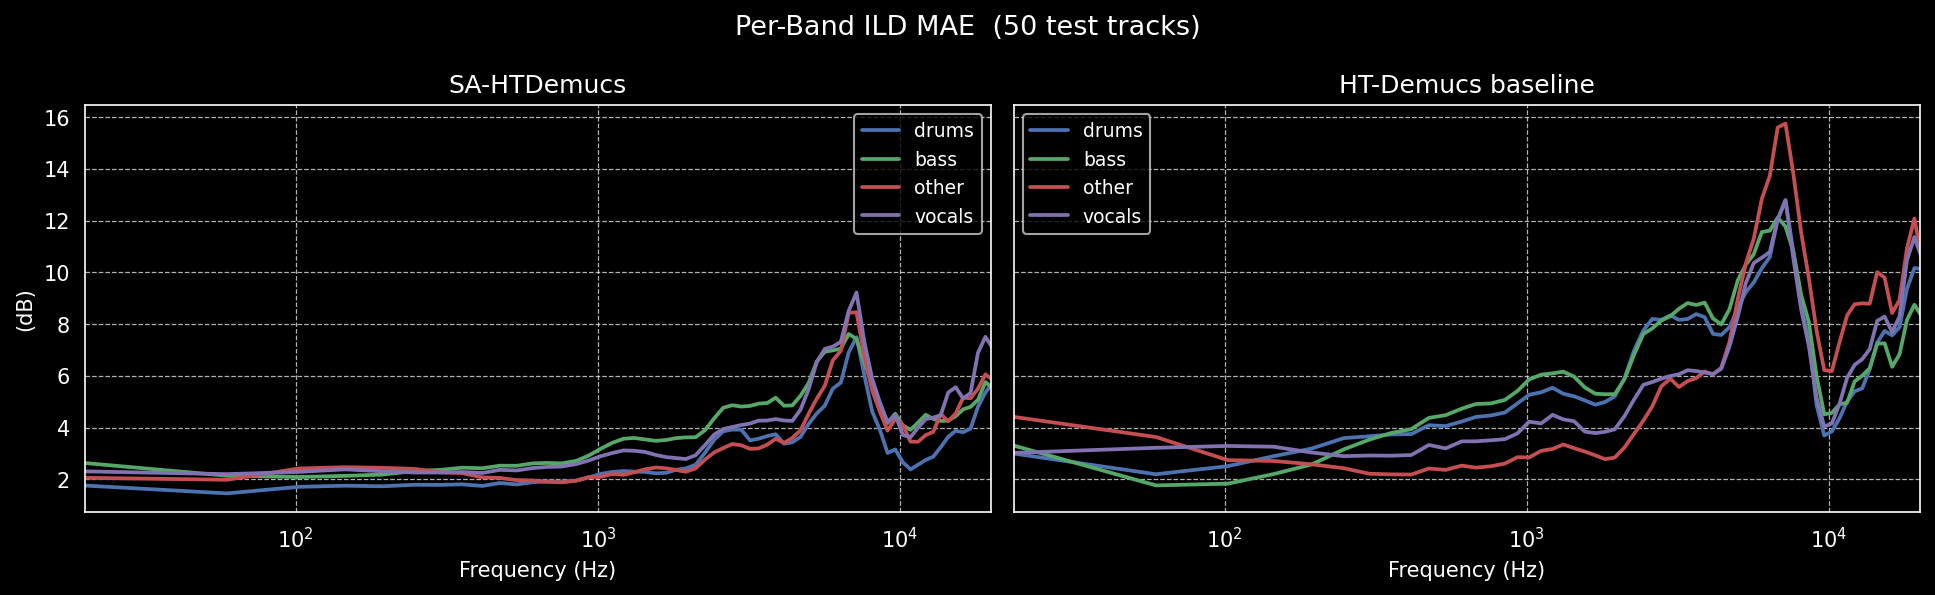

Saved per-band ILD MAE to /nas/home/macerbi/sahtdemucs/runs/ild_mae_per_band_20260527_145610.zip


In [15]:
n_bands  = len(next(iter(stats["mean_ild_mae_bands"].values())))
# Band centre frequencies: linear midpoints for linear bands,
# mean Hz per Mel band for Mel bands (x-axis of the MAE plot).
if _EVAL_SCALE == 'mel':
    _ba     = mel_bin_assignment(int(_EVAL_N_FFT), n_bands, int(_EVAL_SR))
    _bin_hz = np.arange(int(_EVAL_N_FFT) // 2 + 1) * (int(_EVAL_SR) / int(_EVAL_N_FFT))
    band_hz = np.array([
        _bin_hz[(_ba == m).numpy()].mean() if (_ba == m).any() else 0.0
        for m in range(n_bands)
    ])
else:
    band_hz = np.linspace(0, SAMPLE_RATE / 2, n_bands, endpoint=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=150, sharey=True)

for ax, (mae_dict, title) in zip(axes, [
    (stats["mean_ild_mae_bands"],    "SA-HTDemucs"),
    (stats_bl["mean_ild_mae_bands"], "HT-Demucs baseline"),
]):
    for i, src in enumerate(SOURCES):
        ax.plot(band_hz, mae_dict[src], label=src, color=COLORS[i], lw=1.8)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("(dB)" if ax is axes[0] else "")
    ax.set_xscale('log')
    ax.set_xlim([20, 2e4])
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

plt.suptitle(f"Per-Band ILD MAE  ({len(results)} test tracks)", fontsize=13)
plt.tight_layout()

if SAVE_PLOT:
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    plt.savefig(PLOT_DIR / "ild_mae_per_band.png", bbox_inches="tight")
plt.show()

# -- Save per-band ILD MAE data as ZIP of tab-separated .txt files -------------
import zipfile, io

_models = [
    ("sahtdemucs", stats["mean_ild_mae_bands"]),
    ("htdemucs",          stats_bl["mean_ild_mae_bands"]),
]

_zip_path = CKPT_DIR / f"ild_mae_per_band_{_run_ts}.zip"
with zipfile.ZipFile(_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for model_tag, mae_dict in _models:
        for src in SOURCES:
            fname = f"ild_mae_per_band_{src}_{model_tag}.txt"
            buf = io.StringIO()
            buf.write("frequency_hz\tild_mae_dB\n")  # header with tab + newline
            for freq, val in zip(band_hz, mae_dict[src]):
                buf.write(f"{freq:.4f}\t{float(val):.6f}\n")  # tab separator + newline
            zf.writestr(fname, buf.getvalue())

print(f"Saved per-band ILD MAE to {_zip_path}")